# Step 5: Identify species

![Step 5 diagram](https://raw.githubusercontent.com/jaewilson07/bird-watcher/main/docs/diagrams/05-step.png)

## What you're building today

Yesterday we answered: *is there a bird?*
Today we answer: *what kind?*

We'll take the bird crop from the detection box, send it to a species classifier, and get a name back. Like "American Robin, 92% confident."

By the end, every bird frame will have a name on it.

## Step 5.1 — Detect vs identify, side by side

- **Detection** = finding WHERE the bird is (a box around it)
- **Identification** = figuring out WHICH bird it is (a name + confidence)

They're separate models trained for separate jobs. We chain them: first detect, then identify the crop.

For identification we'll use a HuggingFace model trained specifically on birds. Way better than asking YOLO "is this an American Robin?" — YOLO only knows it's a bird, not what kind.

In [1]:
%pip install -q transformers torch torchvision Pillow
print("OK")

/home/jaewilson07/GitHub/bird-watcher/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.
OK


## Step 5.2 — Load the species classifier

We're using `dennisjooo/Birds-Classifier`, a small but accurate model hosted on HuggingFace. This notebook downloads a local snapshot into `data/models/` and keeps the Hub cache in `data/.cache/huggingface`, so it doesn't depend on the global cache.

It knows ~500 common North American and European bird species.

In [6]:
from huggingface_hub import snapshot_download
from transformers import pipeline
from pathlib import Path
import os

from dotenv import load_dotenv

assert load_dotenv(), "Failed to load .env file. Make sure you have a .env file with HUGGINGFACE_API_KEY set."

HF_TOKEN = os.environ["HUGGINGFACE_API_KEY"]

HF_CACHE_DIR = Path("data/.cache/huggingface")
HF_CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ["HF_HOME"] = str(HF_CACHE_DIR)

MODEL_DIR = Path("data/models/Birds-Classifier-EfficientNetB2")

MODEL_DIR.parent.mkdir(parents=True, exist_ok=True)

snapshot_download(
    repo_id="dennisjooo/Birds-Classifier-EfficientNetB2",
    local_dir=MODEL_DIR,
    local_dir_use_symlinks=False,
    cache_dir=HF_CACHE_DIR,
    token=HF_TOKEN if HF_TOKEN else None,
)

classifier = pipeline(
    task="image-classification",
    model=MODEL_DIR,
    token=HF_TOKEN if HF_TOKEN else None,
)
print(f"Loaded classifier. Knows {len(classifier.model.config.id2label)} species.")

Loading weights: 100%|██████████| 508/508 [00:00<00:00, 8082.43it/s]

Loaded classifier. Knows 525 species.


## Step 5.3 — Detect first, then crop the bird
We chain the two: YOLO finds the bird, then we slice that part of the image out and feed the slice to the species classifier.

we detected the 1 bird


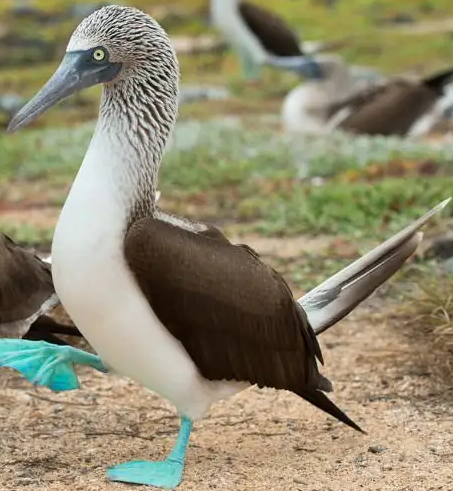

we detected the 2 bird


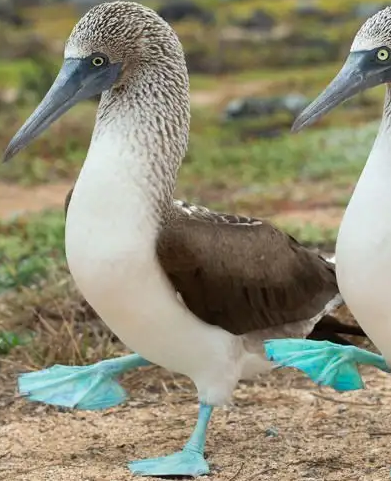

we detected the 3 bird


we detected the 4 bird


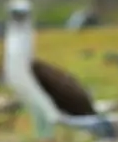

In [26]:
from dotenv import load_dotenv
from ultralytics import YOLO

def detect_bird(image_path):
    detector = YOLO("yolov8n.pt")
    results = detector(image_path, verbose=False)

    BIRD_CLASS_ID = 14
    return [b for b in results[0].boxes  if int(b.cls[0]) == BIRD_CLASS_ID and float(b.conf[0]) > 0.4]
    

def print_bird(bird_boxes, image_path):
    if not bird_boxes:
        print("No birds detected.")
        return

    for idx, box in enumerate(bird_boxes):
        x1, y1, x2, y2 = [int(v) for v in box.xyxy[0]]
        # print(f"Detected bird bounding box: ({x1}, {y1}), ({x2}, {y2})")
        
        img = Image.open(image_path)
        crop = img.crop((x1, y1, x2, y2))
        print(f"we detected the {idx + 1} bird")
        display(crop)

TEST_IMAGE_FILE = "/home/jaewilson07/GitHub/bird-watcher/data/samples/blue-footed-booby.png"

bird_boxes = detect_bird(TEST_IMAGE_FILE)
print_bird(bird_boxes, TEST_IMAGE_FILE)


we detected the 1 bird


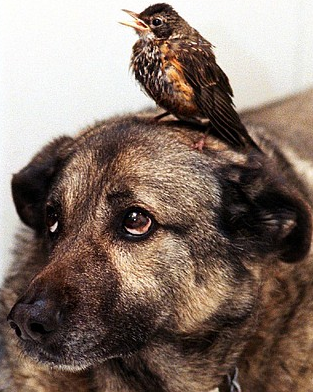

In [30]:

from PIL import Image
from IPython.display import display

TEST_IMAGES = [
    # "/home/jaewilson07/GitHub/bird-watcher/data/samples/blue-footed-booby.png", 
               "/home/jaewilson07/GitHub/bird-watcher/data/samples/dog_bird.jpg"]

for bird in TEST_IMAGES:
    bird_boxes = detect_bird(bird)
    print_bird(bird_boxes, bird)



## Step 5.4 — Identify the species

Hand the crop to the classifier. It returns its top guesses with confidence scores.

In [ ]:
predictions = classifier(crop)

# Print the top 3 guesses
for i, pred in enumerate(predictions[:3]):
    print(f"  {i+1}. {pred['label']:30s}  ({pred['score']:.2f})")

best = predictions[0]
print(f"\nspecies: {best['label']} ({best['score']:.2f})")

## Done?

If you saw something like:

```
species: American Robin (0.92)
```

...then the brain can name names. 🎉

If the species is wrong, don't worry — the classifier is ~85% accurate on common birds. As long as the right family is in the top 3, you've succeeded.

## What's next

Issue **#6: Persist sightings**. Right now every frame's species lives in the notebook, then disappears when you close it. Next we save them to a database so you can look back at what flew by. 🐦